**<p style="font-size:24px;">Project description</p>**

<p style="font-size:14px;">The "One-Click" online store has experienced a decline in purchasing activity among regular customers. Attracting new buyers is becoming less efficient, so the main goal of the project is to develop a solution for customer retention through personalized offers.
The company wants to make decisions based on data and modeling.</p>



**<p style="font-size:18px;">As part of the project, it is required to:</p>**


- Build a model to predict the probability of a decrease in activity.


- Perform customer segmentation.


- Develop recommendations to increase purchasing activity.

**<p style="font-size:18px;">Research Progress</p>**
**<p style="font-size:18px;">The following steps were performed during the project:</p>**



- Loading and examining data from multiple sources.


- Preprocessing: handling missing values, feature encoding, scaling.


- Exploratory data analysis and merging tables.


- Correlation analysis and testing for multicollinearity.


- Training and comparing models (KNN, DecisionTree, LogisticRegression, SVC) with hyperparameter tuning.


- Determining feature importance using SHAP.


- Customer segmentation and analysis of the selected group.


- Developing personalized recommendations for customer retention.

In [191]:
!pip install shap -q
!pip install phik -q


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler, 
    OneHotEncoder, 
    OrdinalEncoder, 
    LabelEncoder)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

from phik import phik_matrix
from phik.report import plot_correlation_matrix
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

### Loading data

In [193]:
market_file = pd.read_csv('market_file.csv')
market_money = pd.read_csv('market_money.csv')
market_time = pd.read_csv('market_time.csv')
money = pd.read_csv('money.csv', sep=';', decimal=',')

In [194]:
market_file.head(), market_file.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   str    
 2   Тип сервиса                          1300 non-null   str    
 3   Разрешить сообщать                   1300 non-null   str    
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   str    
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                       1300

(       id Покупательская активность Тип сервиса Разрешить сообщать  \
 0  215348                 Снизилась     премиум                 да   
 1  215349                 Снизилась     премиум                 да   
 2  215350                 Снизилась   стандартт                нет   
 3  215351                 Снизилась   стандартт                 да   
 4  215352                 Снизилась   стандартт                нет   
 
    Маркет_актив_6_мес  Маркет_актив_тек_мес  Длительность  Акционные_покупки  \
 0                 3.4                     5           121               0.00   
 1                 4.4                     4           819               0.75   
 2                 4.9                     3           539               0.14   
 3                 3.2                     5           896               0.99   
 4                 5.1                     3          1064               0.94   
 
   Популярная_категория  Средний_просмотр_категорий_за_визит  \
 0     Товары для де

In [195]:
market_money.info(), market_money.head()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   str    
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 91.5 KB


(None,
        id               Период  Выручка
 0  215348  препредыдущий_месяц      0.0
 1  215348        текущий_месяц   3293.1
 2  215348     предыдущий_месяц      0.0
 3  215349  препредыдущий_месяц   4472.0
 4  215349        текущий_месяц   4971.6)

In [196]:
market_time.info(), market_money.head()

<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2600 non-null   int64
 1   Период  2600 non-null   str  
 2   минут   2600 non-null   int64
dtypes: int64(2), str(1)
memory usage: 61.1 KB


(None,
        id               Период  Выручка
 0  215348  препредыдущий_месяц      0.0
 1  215348        текущий_месяц   3293.1
 2  215348     предыдущий_месяц      0.0
 3  215349  препредыдущий_месяц   4472.0
 4  215349        текущий_месяц   4971.6)

In [197]:
money.info(), money.head()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


(None,
        id  Прибыль
 0  215348     0.98
 1  215349     4.16
 2  215350     3.13
 3  215351     4.87
 4  215352     4.21)

**<p style="font-size:14px;">The data in the tables corresponds to the description.</p>**


### Data preprocessing

In [198]:
def data_preprocessing(data):
    data.columns = data.columns.str.replace(' ', '_', regex=True).str.lower()
    duplicates_count = data.duplicated().sum()

    missing_values_count = data.isnull().sum().sum()

    data = data.drop_duplicates()

    print(f'Number of explicit duplicates: {duplicates_count}')
    print(f'Number of missing values: {missing_values_count}')
    print(f'The dimensions of the dataset after removing duplicates: {data.shape}',)
    print('\n\n')
    
    return data

In [199]:
dataframes = [market_file, market_money, market_time, money]

for dataframe in dataframes:
    dataframe = data_preprocessing(dataframe)

Number of explicit duplicates: 0
Number of missing values: 0
The dimensions of the dataset after removing duplicates: (1300, 13)



Number of explicit duplicates: 0
Number of missing values: 0
The dimensions of the dataset after removing duplicates: (3900, 3)



Number of explicit duplicates: 0
Number of missing values: 0
The dimensions of the dataset after removing duplicates: (2600, 3)



Number of explicit duplicates: 0
Number of missing values: 0
The dimensions of the dataset after removing duplicates: (1300, 2)




**The data is normal, no missing values or explicit duplicates were found, and the data types correspond to their values. Let's start looking for implicit duplicates.**


In [200]:
market_file['тип_сервиса'].unique()

<StringArray>
['премиум', 'стандартт', 'стандарт']
Length: 3, dtype: str

In [201]:
market_file['тип_сервиса'] = market_file['тип_сервиса'].replace('стандартт', 'стандарт', regex=True)


In [202]:
market_time['период'].unique()


<StringArray>
['текущий_месяц', 'предыдцщий_месяц']
Length: 2, dtype: str

In [203]:
market_time['период'] = market_time['период'].replace('предыдцщий_месяц', 'предыдущий_месяц', regex=True)


**The data has been successfully preprocessed: missing values and duplicates (explicit and implicit) have been handled, data types have been converted, and categorical features have been prepared for encoding.**

### Exploratory data analysis

In [204]:
pivot_money = market_money.pivot_table(
    index='id',
    columns='период',
    values='выручка',
    aggfunc='sum',  
)

pivot_money.head()

период,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
id,,,
215348,0.0,0.0,3293.1
215349,5216.0,4472.0,4971.6
215350,5457.5,4826.0,5058.4
215351,6158.0,4793.0,6610.4
215352,5807.5,4594.0,5872.5


In [205]:
active_clients = pivot_money[(pivot_money > 0).all(axis=1)].index

len(active_clients)

1297

In [206]:
market_file = market_file[market_file['id'].isin(active_clients)]
market_money = market_money[market_money['id'].isin(active_clients)]
market_time = market_time[market_time['id'].isin(active_clients)]
money = money[money['id'].isin(active_clients)]


**Data is ready for exploratory analysis**

1. market_file

In [207]:
market_file.describe()

,id,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
count,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000
mean,215998.986893,4.254433,4.009252,602.993832,0.320547,3.267540,2.841172,4.184271,8.186584
std,374.578554,1.015618,0.696048,249.101456,0.249657,1.354623,1.973451,1.950973,3.977061
min,215349.000000,0.900000,3.000000,121.000000,0.110000,1.000000,0.000000,0.000000,1.000000
25%,215675.000000,3.700000,4.000000,410.000000,0.170000,2.000000,1.000000,3.000000,5.000000
50%,215999.000000,4.200000,4.000000,607.000000,0.240000,3.000000,3.000000,4.000000,8.000000
75%,216323.000000,4.900000,4.000000,806.000000,0.300000,4.000000,4.000000,6.000000,11.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.000000,10.000000,9.000000,20.000000


Market activity for 6 months

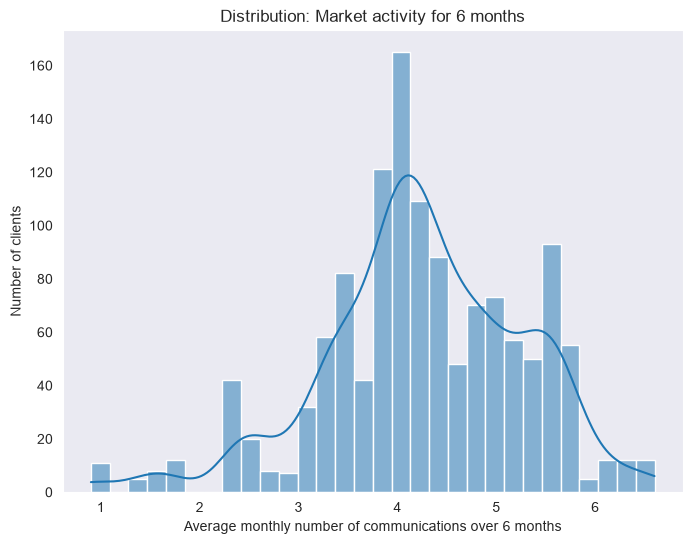

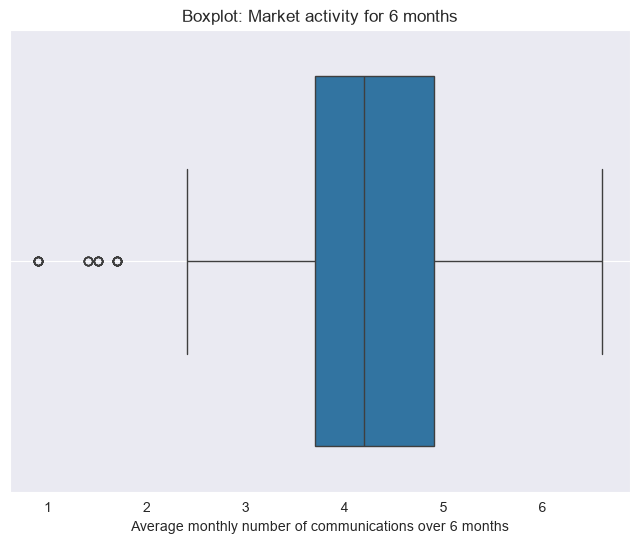

In [208]:
plt.figure(figsize=(8, 6))
sns.histplot(market_file['маркет_актив_6_мес'], bins=30, kde=True)
plt.title('Distribution: Market activity for 6 months')
plt.xlabel('Average monthly number of communications over 6 months')
plt.ylabel('Number of clients')
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=market_file['маркет_актив_6_мес'])
plt.title('Boxplot: Market activity for 6 months')
plt.xlabel('Average monthly number of communications over 6 months')
plt.grid()
plt.show()

Market activity for current months

C:\Users\nelli\AppData\Local\Temp\ipykernel_13172\743459586.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='маркет_актив_тек_мес', data=market_file, palette='viridis')


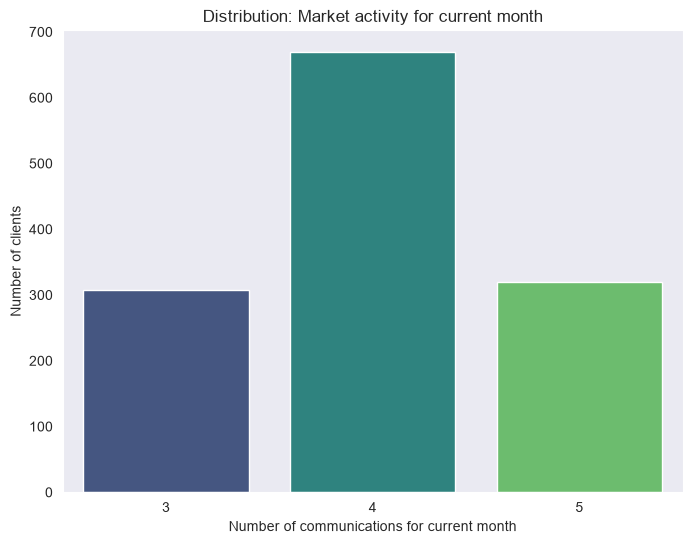

In [209]:
plt.figure(figsize=(8, 6))
sns.countplot(x='маркет_актив_тек_мес', data=market_file, palette='viridis')
plt.title('Distribution: Market activity for current month')
plt.xlabel('Number of communications for current month')
plt.ylabel('Number of clients')
plt.grid(axis='y')
plt.show()



Discrete values are observed in the distribution.

Duration

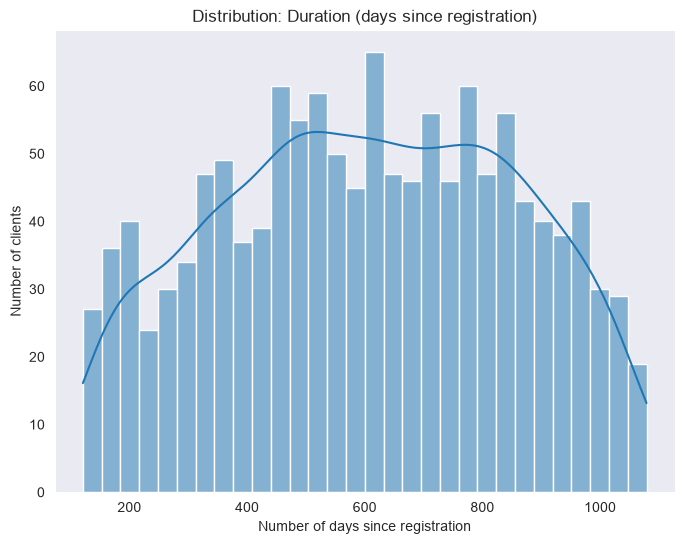

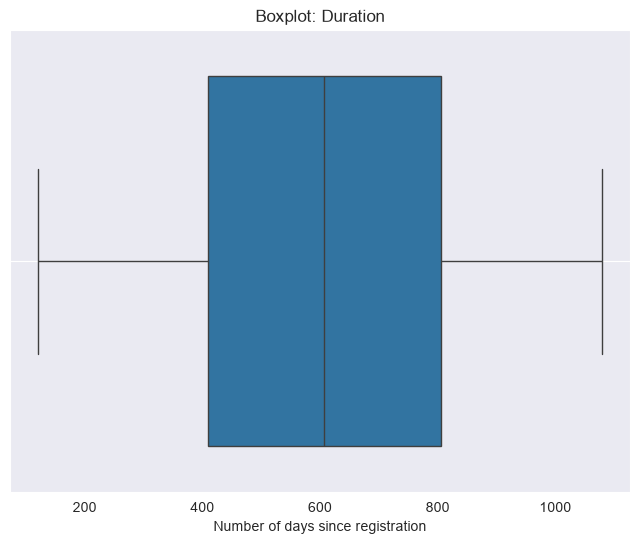

In [210]:
plt.figure(figsize=(8, 6))
sns.histplot(market_file['длительность'], bins=30, kde=True)
plt.title('Distribution: Duration (days since registration)')
plt.xlabel('Number of days since registration')
plt.ylabel('Number of clients')
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=market_file['длительность'])
plt.title('Boxplot: Duration')
plt.xlabel('Number of days since registration')
plt.grid()
plt.show()

Promotional purchases

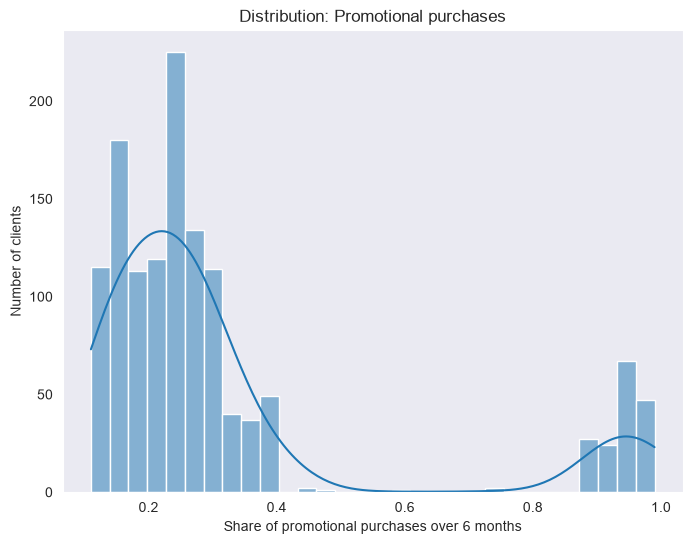

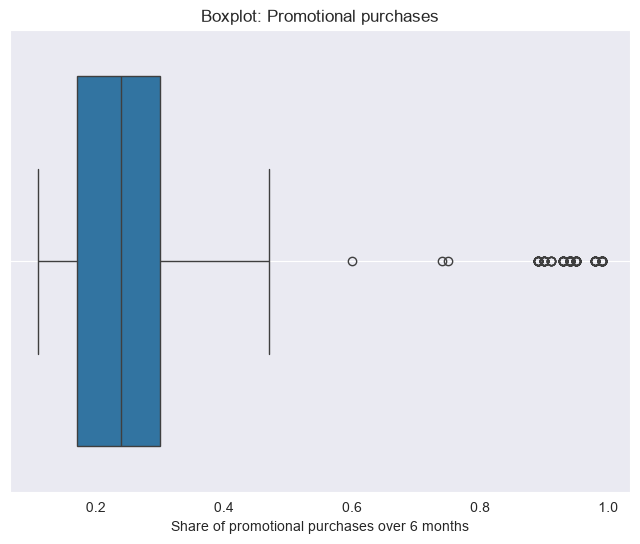

In [211]:
plt.figure(figsize=(8, 6))
sns.histplot(market_file['акционные_покупки'], bins=30, kde=True)
plt.title('Distribution: Promotional purchases')
plt.xlabel('Share of promotional purchases over 6 months')
plt.ylabel('Number of clients')
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=market_file['акционные_покупки'])
plt.title('Boxplot: Promotional purchases')
plt.xlabel('Share of promotional purchases over 6 months')
plt.grid()
plt.show()

Average category views per visit

C:\Users\nelli\AppData\Local\Temp\ipykernel_13172\1859724851.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='средний_просмотр_категорий_за_визит', data=market_file, palette='viridis')


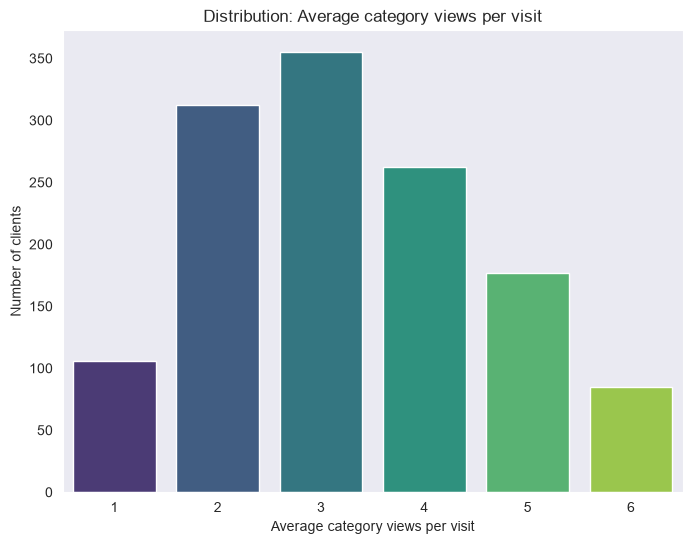

In [212]:
plt.figure(figsize=(8, 6))
sns.countplot(x='средний_просмотр_категорий_за_визит', data=market_file, palette='viridis')
plt.title('Distribution: Average category views per visit')
plt.xlabel('Average category views per visit')
plt.ylabel('Number of clients')
plt.grid(axis='y')
plt.show()



Unpaid products

C:\Users\nelli\AppData\Local\Temp\ipykernel_13172\2737096709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='неоплаченные_продукты_штук_квартал', data=market_file, palette='viridis')


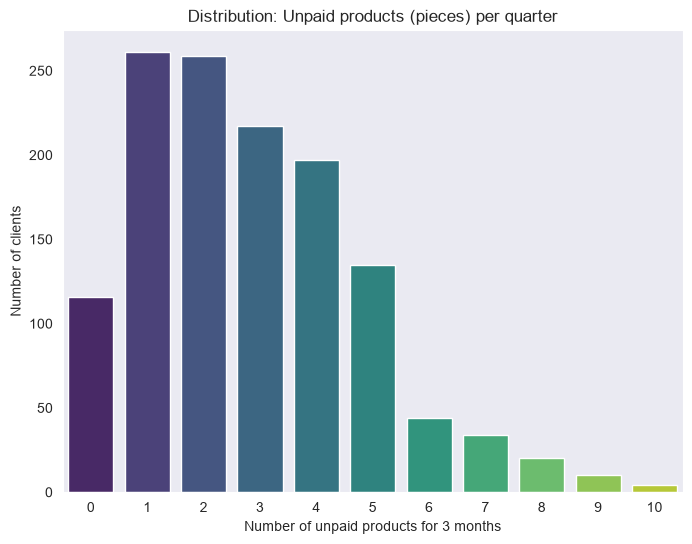

In [213]:
plt.figure(figsize=(8, 6))
sns.countplot(x='неоплаченные_продукты_штук_квартал', data=market_file, palette='viridis')
plt.title('Distribution: Unpaid products (pieces) per quarter')
plt.xlabel('Number of unpaid products for 3 months')
plt.ylabel('Number of clients')
plt.grid(axis='y')
plt.show()



Service error

C:\Users\nelli\AppData\Local\Temp\ipykernel_13172\1821610876.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ошибка_сервиса', data=market_file, palette='viridis')


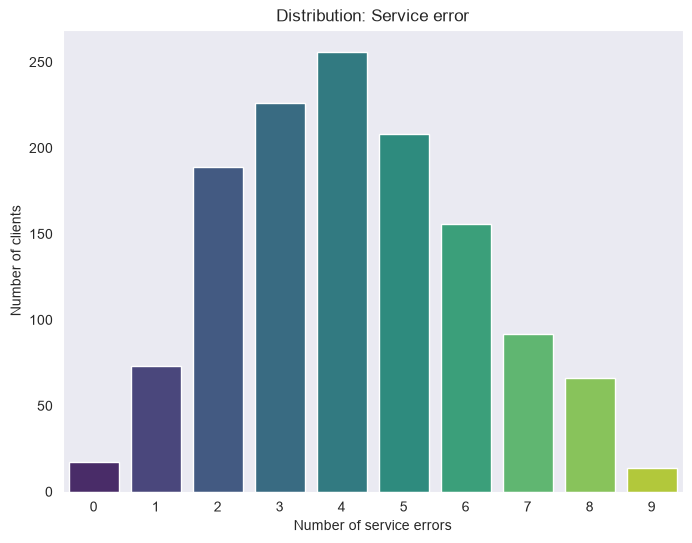

In [214]:
plt.figure(figsize=(8, 6))
sns.countplot(x='ошибка_сервиса', data=market_file, palette='viridis')

plt.title('Distribution: Service error')
plt.xlabel('Number of service errors')
plt.ylabel('Number of clients')
plt.grid(axis='y')
plt.show()



Pages per visit

C:\Users\nelli\AppData\Local\Temp\ipykernel_13172\3767321457.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='страниц_за_визит', data=market_file, palette='viridis')


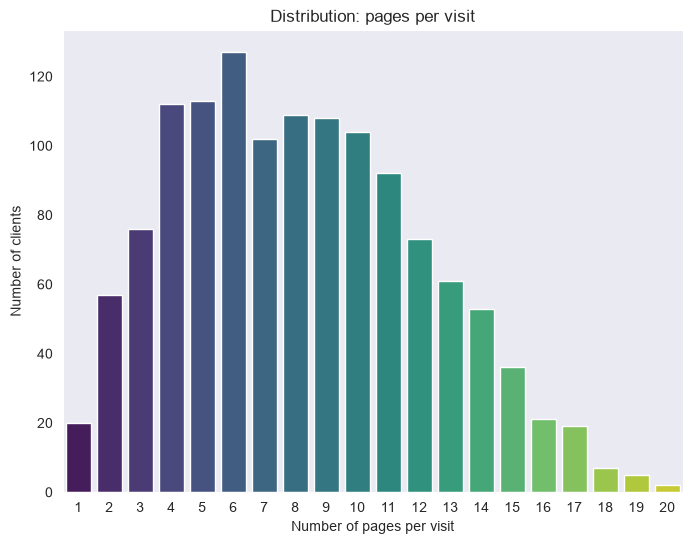

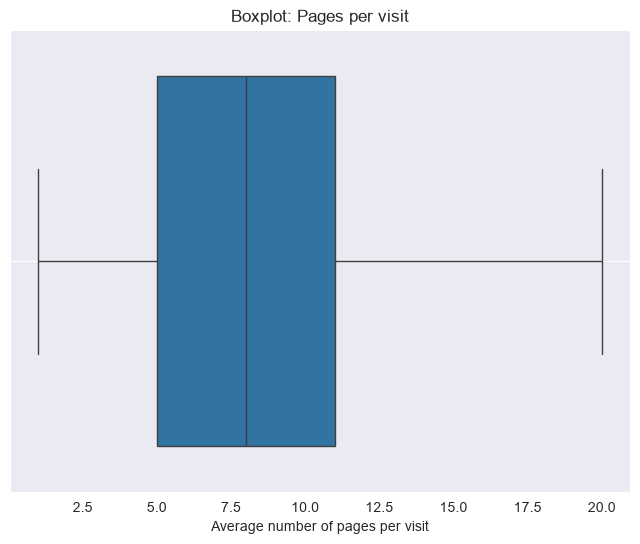

In [215]:
plt.figure(figsize=(8, 6))
sns.countplot(x='страниц_за_визит', data=market_file, palette='viridis')

plt.title('Distribution: pages per visit')
plt.xlabel('Number of pages per visit')
plt.ylabel('Number of clients')
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=market_file['страниц_за_визит'])
plt.title('Boxplot: Pages per visit')
plt.xlabel('Average number of pages per visit')
plt.grid()
plt.show()

Purchasing activity

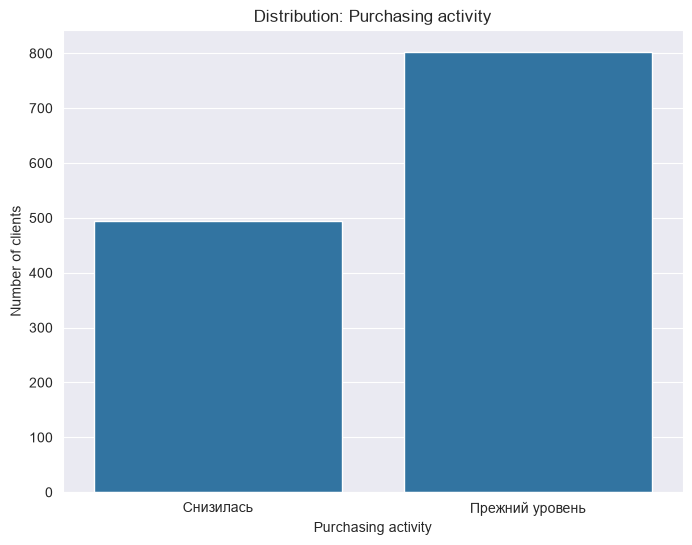

In [216]:
plt.figure(figsize=(8, 6))
sns.countplot(x='покупательская_активность', data=market_file)
plt.title('Distribution: Purchasing activity')
plt.xlabel('Purchasing activity')
plt.ylabel('Number of clients')
plt.show()

The majority of customers maintained their previous activity level.

Service type

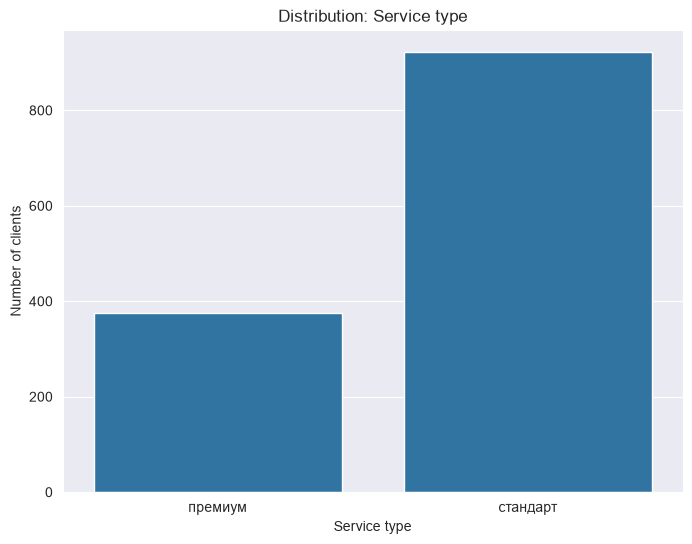

In [217]:
plt.figure(figsize=(8, 6))
sns.countplot(x='тип_сервиса', data=market_file)
plt.title('Distribution: Service type')
plt.xlabel('Service type')
plt.ylabel('Number of clients')
plt.show()

Fewer users use Premium, which fits reality quite well.

Mailing list permission

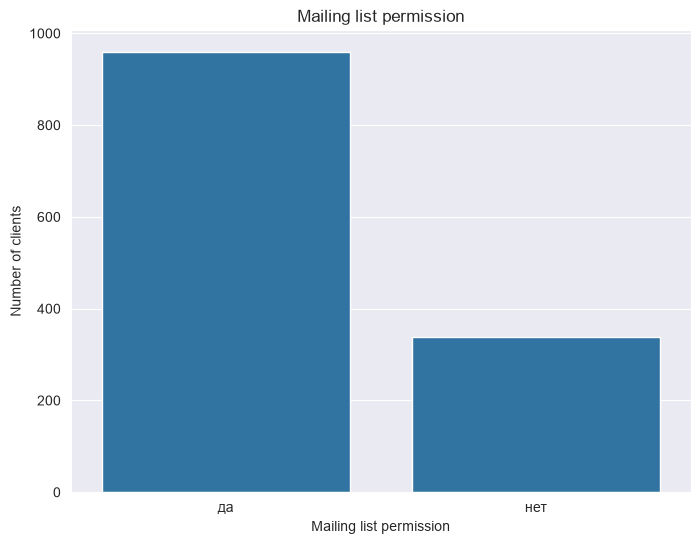

In [218]:
plt.figure(figsize=(8, 6))
sns.countplot(x='разрешить_сообщать', data=market_file)
plt.title('Mailing list permission')
plt.xlabel('Mailing list permission')
plt.ylabel('Number of clients')
plt.show()

Popular category

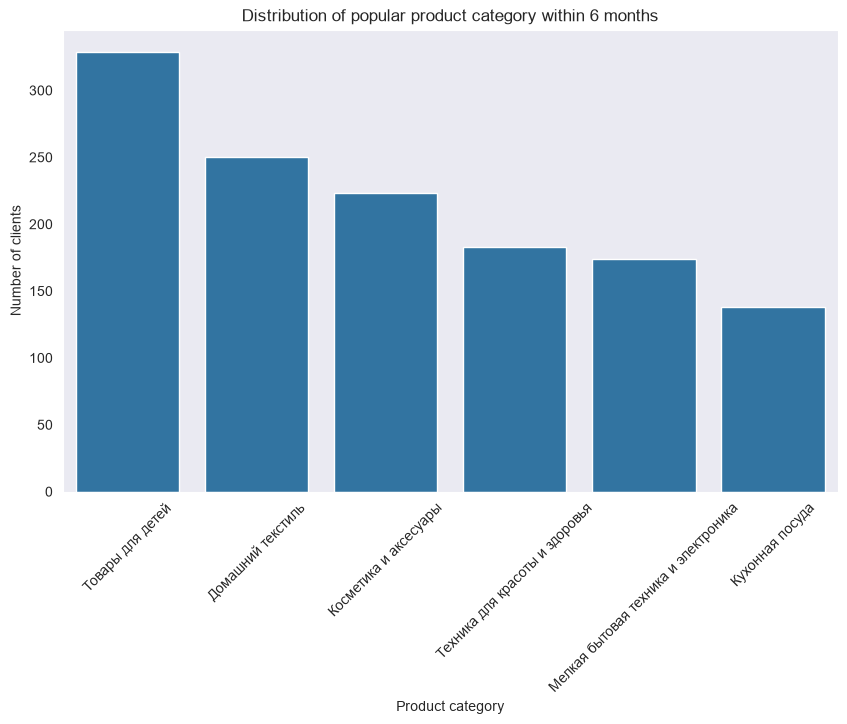

In [219]:
plt.figure(figsize=(10, 6))
sns.countplot(data=market_file, x='популярная_категория', order=market_file['популярная_категория'].value_counts().index)
plt.title('Distribution of popular product category within 6 months')
plt.xlabel('Product category')
plt.ylabel('Number of clients')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

2. market_money


In [220]:
pivot_money.head()

период,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
id,,,
215348,0.0,0.0,3293.1
215349,5216.0,4472.0,4971.6
215350,5457.5,4826.0,5058.4
215351,6158.0,4793.0,6610.4
215352,5807.5,4594.0,5872.5


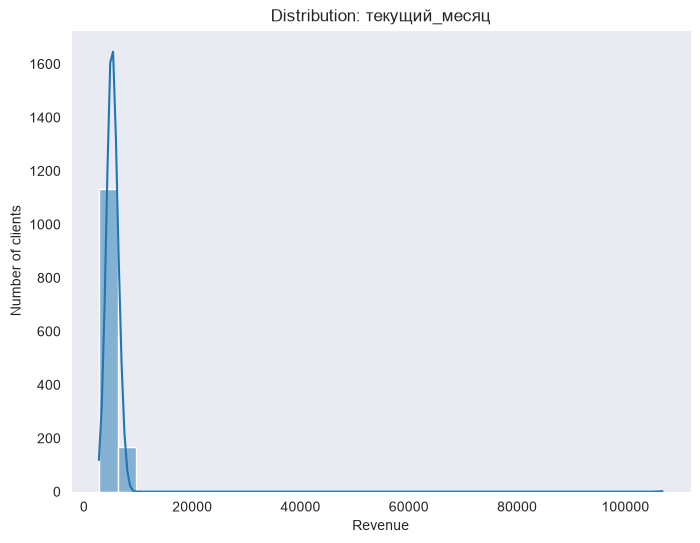

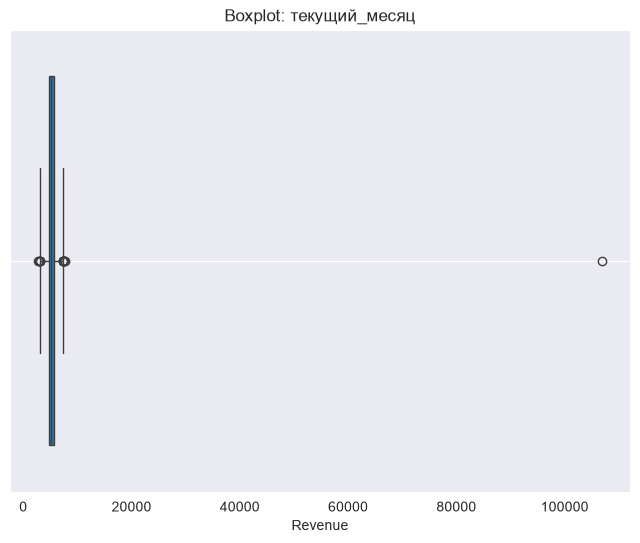

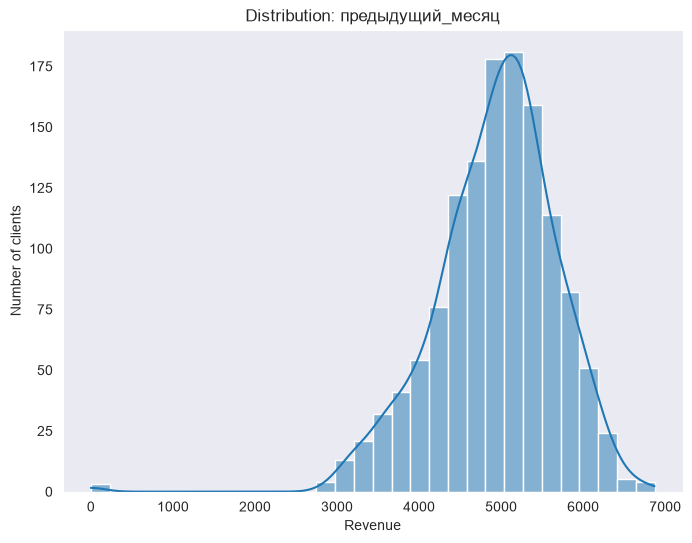

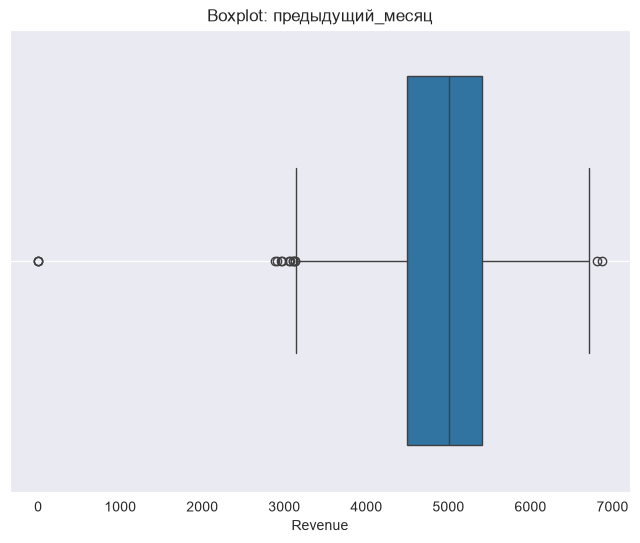

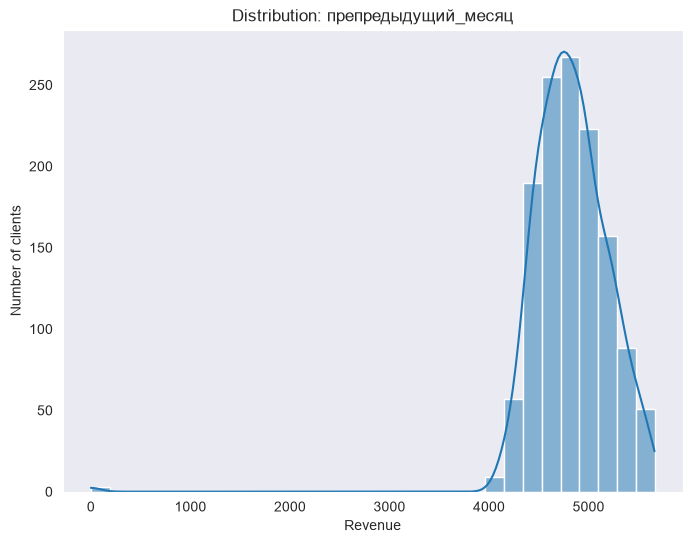

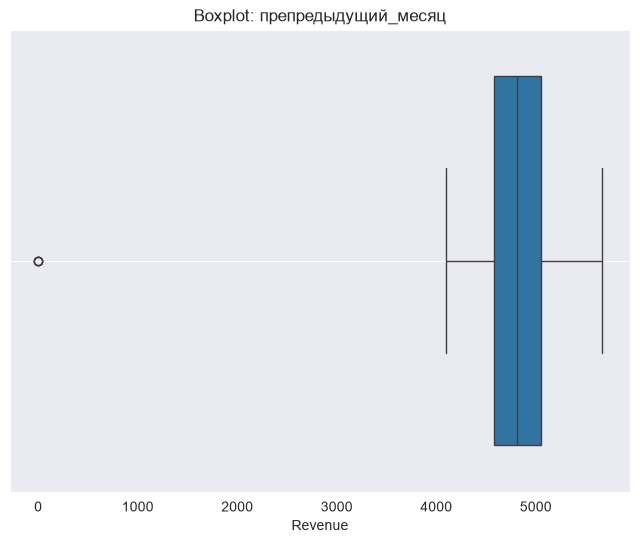

In [221]:
cols = ['текущий_месяц', 'предыдущий_месяц', 'препредыдущий_месяц']

for col in cols: 
    plt.figure(figsize=(8, 6))
    sns.histplot(pivot_money[col], bins=30, kde=True)
    plt.title(f'Distribution: {col}')
    plt.xlabel('Revenue')
    plt.ylabel('Number of clients')
    plt.grid()
    plt.show()

    # Boxplot
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=pivot_money[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel('Revenue')
    plt.grid()
    plt.show()

In [222]:
market_money = market_money.query('выручка < 20000')


3. market_time

In [223]:
pivot_time = market_time.pivot(index='id', columns='период', values='минут').reset_index()

pivot_time.head()


период,id,предыдущий_месяц,текущий_месяц
0,215349,12,10
1,215350,8,13
2,215351,11,13
3,215352,8,11
4,215353,10,10


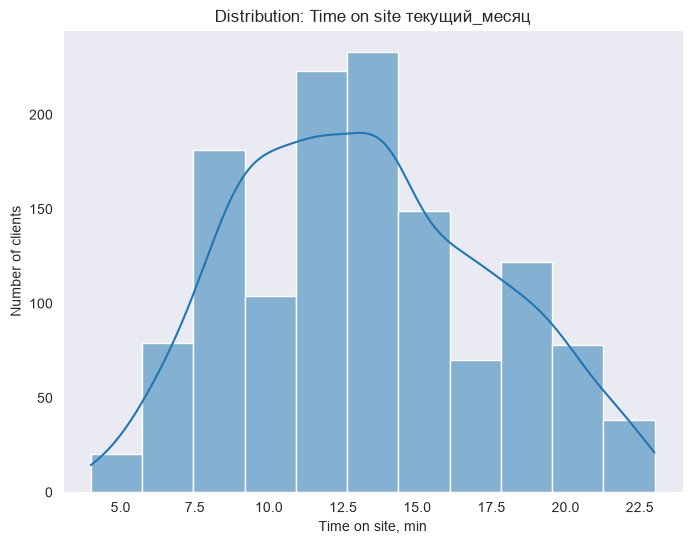

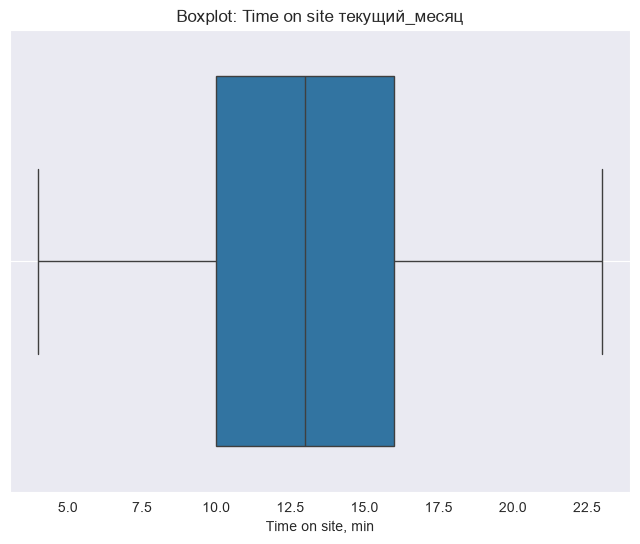

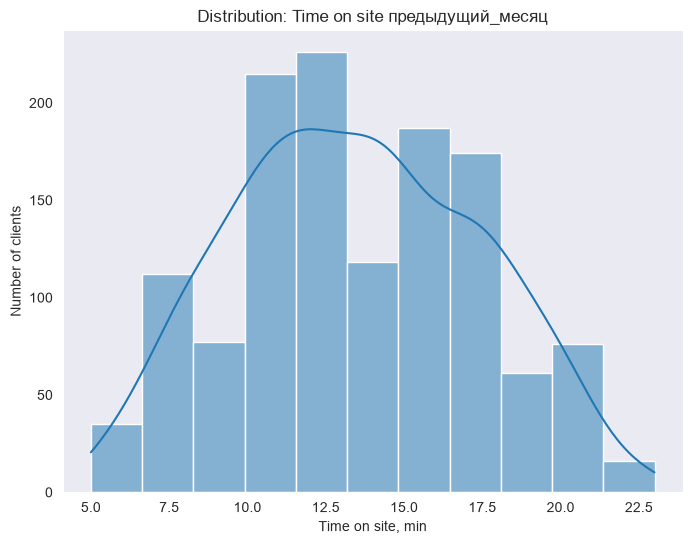

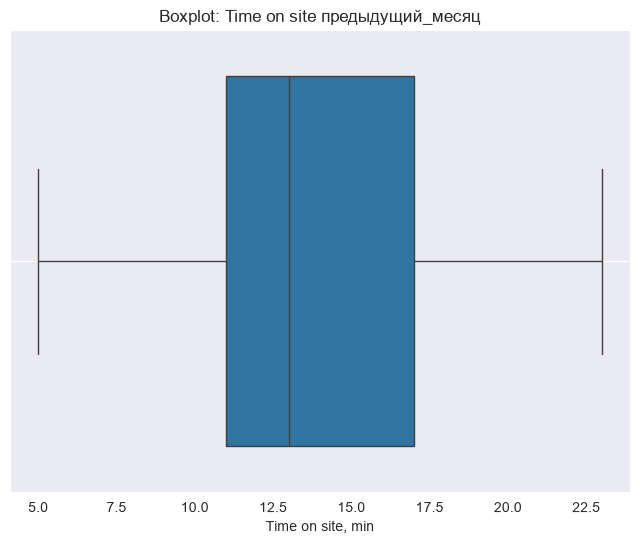

In [224]:
cols = ['текущий_месяц', 'предыдущий_месяц']

for col in cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(pivot_time[col], bins=11, kde=True)
    plt.title(f"Distribution: Time on site {col}")
    plt.xlabel('Time on site, min')
    plt.ylabel('Number of clients')
    plt.grid()
    plt.show() 

    plt.figure(figsize=(8, 6))
    sns.boxplot(x=pivot_time[col])
    plt.title(f"Boxplot: Time on site {col}")
    plt.xlabel('Time on site, min')
    plt.grid()
    plt.show()

4. money

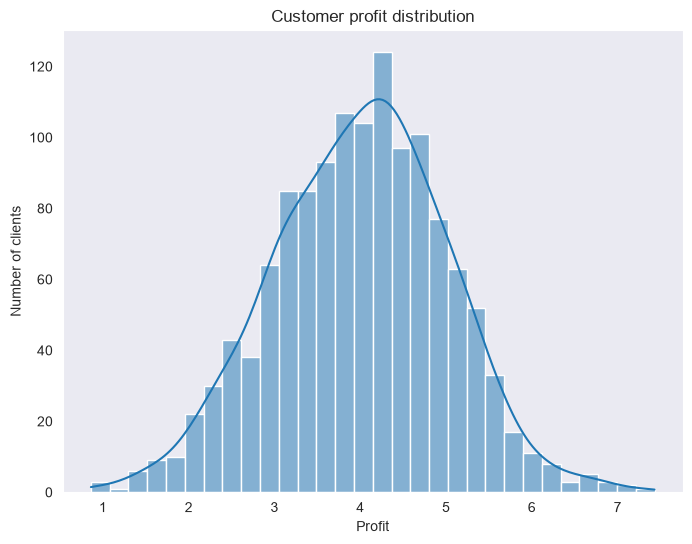

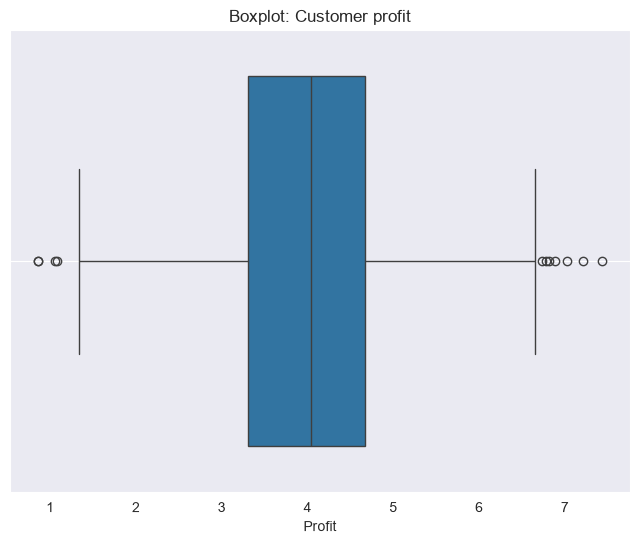

In [225]:
plt.figure(figsize=(8, 6))
sns.histplot(money['прибыль'], bins=30, kde=True)
plt.title('Customer profit distribution')
plt.xlabel('Profit')
plt.ylabel('Number of clients')
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=money['прибыль'])
plt.title('Boxplot: Customer profit')
plt.xlabel('Profit')
plt.grid()
plt.show()

**During the exploratory analysis, key customer characteristics were examined. Users with a purchasing activity of less than three months were excluded from the sample to ensure model quality.**

- Marketing activity over 6 months: The optimal level of marketing communication is about 4 contacts per month per customer. At this level, the highest concentration of buyers is observed.


- Marketing activity for the current month: In the current month, customers most frequently receive 4 marketing contacts. This value can be considered a comfortable interaction norm.


- Duration: Most customers remain active for about 600 days from registration. It is recommended to increase marketing efforts during this period to improve retention.


- Promotional purchases: Most customers make about 30% of their purchases via promotions. Very few buy half or more through promotions, and there is a small group that buys exclusively through promotions. This means that promotions stimulate some customers, but not all. Loyalty can be strengthened through personalized offers, and promotion-dependent customers should be studied to manage risks.


- Average category views per visit: During a single visit, customers typically view approximately 3 categories—an optimal number indicating they are interested without being overwhelmed by choice.


- Number of unpaid items over 3 months: Most customers leave no more than 1 unpaid item in their cart per quarter. Higher instances are rare.


- Number of service errors: Most customers encounter 4 service errors per visit; the distribution resembles a normal distribution. This is a signal of potential website issues that may degrade the customer experience and impact sales—working on stability is advised.


- Average number of pages per visit: The majority of customers view about 6 pages per visit—an optimal level of engagement where users explore the assortment without getting lost on the site. A gradual decline in activity after 8 pages indicates waning interest or visitor fatigue. For the business, this is a signal to optimize navigation and content to retain attention and encourage a swift transition to purchase, as well as to consider ways to engage those prone to viewing more pages to increase the average check.


- Purchasing activity: The majority of buyers (about 800) maintain stable activity, while a significant yet smaller group (about 500) has decreased their activity. This means that to retain and stimulate growth, the focus should be on returning and engaging the declining group while supporting loyal customers with consistent activity.


- Service type: Most customers (about 800) choose the standard service, whereas slightly under 400 customers prefer the premium service. This indicates that the standard service is in higher demand, but the premium segment holds growth potential through improved offerings and marketing.


- Mailing list permission: Most customers agree to receive additional offers, opening up good opportunities for personalized promotions and increased sales. A smaller portion opted out, so it is important to respect their choice and maintain service quality.


- Popular category: Shoppers most frequently choose children's goods, home textiles, and cosmetics. Less popular are beauty gadgets, small home appliances, and kitchenware. The primary interest lies in children's and home categories, which is important to consider when planning promotions and product assortment.







### Merging tables

In [226]:
pivot_money = pivot_money.rename(columns={
    'текущий_месяц': 'выручка_текущий_месяц',
    'предыдущий_месяц': 'выручка_предыдущий_месяц',
    'препредыдущий_месяц': 'выручка_препредыдущий_месяц'
})    
    
    
pivot_time = pivot_time.rename(columns={
    'текущий_месяц': 'время_текущий_месяц',
    'предыдущий_месяц': 'время_предыдущий_месяц',
    'препредыдущий_месяц': 'время_препредыдущий_месяц'
})
    
pivot_money.info(), pivot_time.info()

<class 'pandas.DataFrame'>
Index: 1300 entries, 215348 to 216647
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   выручка_предыдущий_месяц     1300 non-null   float64
 1   выручка_препредыдущий_месяц  1300 non-null   float64
 2   выручка_текущий_месяц        1300 non-null   float64
dtypes: float64(3)
memory usage: 40.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      1297 non-null   int64
 1   время_предыдущий_месяц  1297 non-null   int64
 2   время_текущий_месяц     1297 non-null   int64
dtypes: int64(3)
memory usage: 30.5 KB


(None, None)

In [227]:
full_data = market_file.merge(pivot_money, on='id', how='inner')

full_data = full_data.merge(pivot_time, on='id', how='inner')

full_data.head(), full_data.info(), full_data.shape

<class 'pandas.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1297 non-null   int64  
 1   покупательская_активность            1297 non-null   str    
 2   тип_сервиса                          1297 non-null   str    
 3   разрешить_сообщать                   1297 non-null   str    
 4   маркет_актив_6_мес                   1297 non-null   float64
 5   маркет_актив_тек_мес                 1297 non-null   int64  
 6   длительность                         1297 non-null   int64  
 7   акционные_покупки                    1297 non-null   float64
 8   популярная_категория                 1297 non-null   str    
 9   средний_просмотр_категорий_за_визит  1297 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1297 non-null   int64  
 11  ошибка_сервиса                       1297

(       id покупательская_активность тип_сервиса разрешить_сообщать  \
 0  215349                 Снизилась     премиум                 да   
 1  215350                 Снизилась    стандарт                нет   
 2  215351                 Снизилась    стандарт                 да   
 3  215352                 Снизилась    стандарт                нет   
 4  215353                 Снизилась    стандарт                 да   
 
    маркет_актив_6_мес  маркет_актив_тек_мес  длительность  акционные_покупки  \
 0                 4.4                     4           819               0.75   
 1                 4.9                     3           539               0.14   
 2                 3.2                     5           896               0.99   
 3                 5.1                     3          1064               0.94   
 4                 3.3                     4           762               0.26   
 
   популярная_категория  средний_просмотр_категорий_за_визит  \
 0     Товары для де

### Correlation analysis

In [228]:
full_data.columns

Index(['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит', 'выручка_предыдущий_месяц',
       'выручка_препредыдущий_месяц', 'выручка_текущий_месяц',
       'время_предыдущий_месяц', 'время_текущий_месяц'],
      dtype='str')

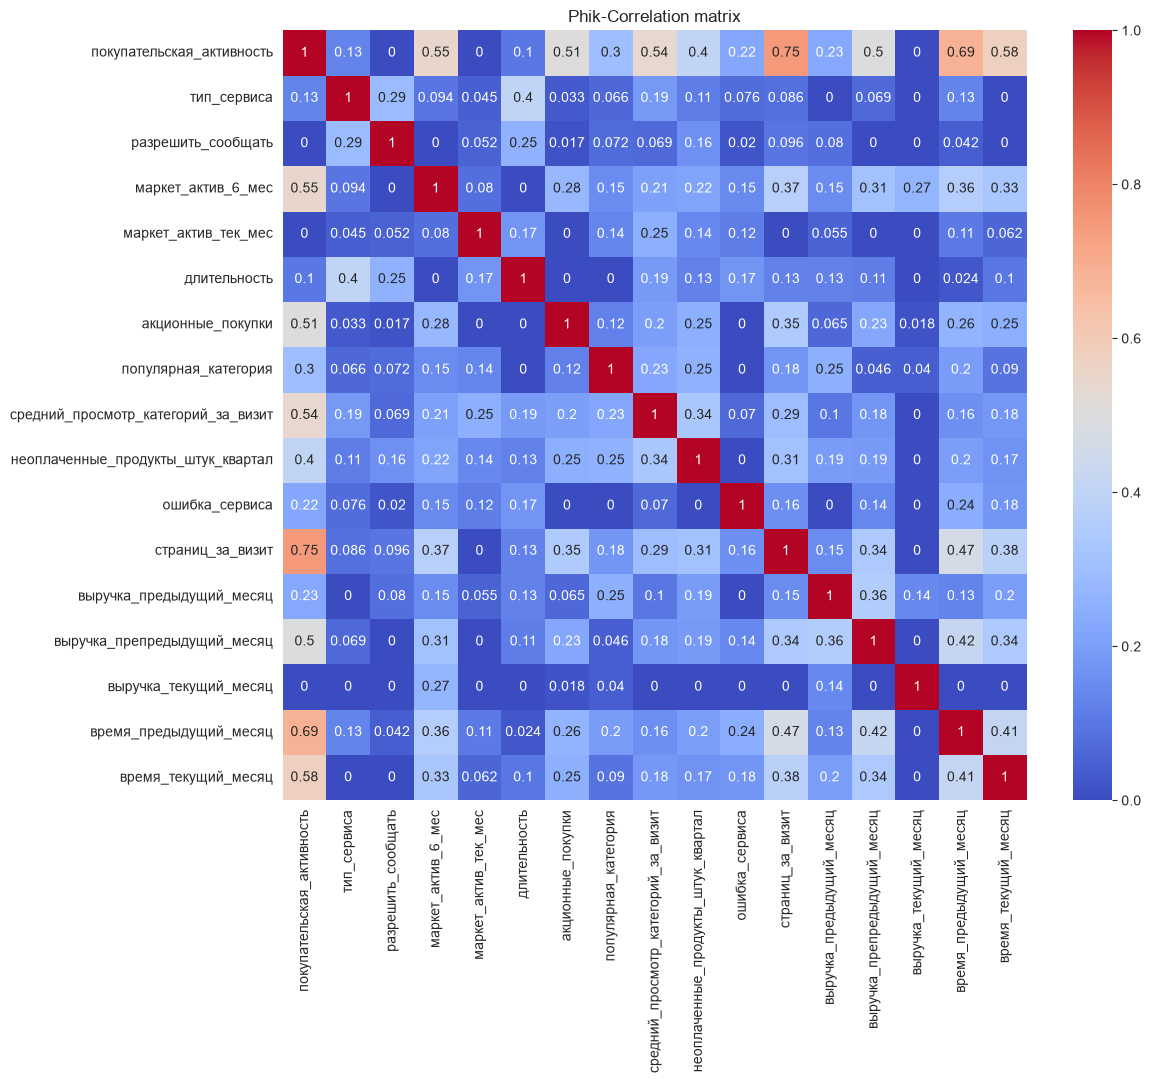

In [229]:
phik_data = full_data.drop(columns=['id'])


phik_corr = phik_data.phik_matrix(interval_cols=['маркет_актив_6_мес', 'длительность', 'акционные_покупки', 
                                                'выручка_предыдущий_месяц',
       'выручка_препредыдущий_месяц', 'выручка_текущий_месяц',
       'время_предыдущий_месяц', 'время_текущий_месяц'])

plt.figure(figsize=(12, 10))
sns.heatmap(phik_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Phik-Correlation matrix')
plt.show()

**<p style="font-size:18px;">The correlation matrix shows that overall, most features have a weak or moderate correlation, but there are a few pairs with a relatively high correlation.</p>**


**Highly correlated feature pairs:**

- pages_per_visit and purchasing_activity — 0.75


- purchasing_activity and time_previous_month — 0.69


- purchasing_activity and time_current_month — 0.58


- pages_per_visit and time_previous_month — 0.47





**<p style="font-size:14px;">Despite the presence of moderate correlation between some features, the correlation coefficients do not exceed the critical value of 0.9, at which multicollinearity begins to significantly impact the model. Since models robust to linear dependencies between features are planned for future use, we are keeping the current feature set unchanged.</p>**

### Creating pipelines

In [230]:
ohe_columns = ['разрешить_сообщать', 'популярная_категория']
ord_columns = ['тип_сервиса']
num_columns = ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 
               'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 
               'ошибка_сервиса', 'страниц_за_визит', 'выручка_препредыдущий_месяц',
               'выручка_предыдущий_месяц','выручка_текущий_месяц' ,'время_предыдущий_месяц', 'время_текущий_месяц']

RANDOM_STATE = 42

X = full_data.drop(['покупательская_активность', 'id'], axis = 1)
y = full_data['покупательская_активность']
X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        random_state=RANDOM_STATE
)  

In [231]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [232]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(handle_unknown='ignore', sparse_output =False)
        )
    ]
) 

In [233]:
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',  
            OrdinalEncoder(
                categories=[
                    ['стандарт', 'премиум']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
) 

In [234]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
         ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
) 

In [235]:
pipe_final= Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [236]:
param_distributions = [
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    },
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 11),
        'models__max_features': range(2, 11),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [SVC(random_state=RANDOM_STATE, probability= True)],
        'models__C': range(1, 10),
        'models__kernel': ['rbf', 'linear', 'sigmoid'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  

    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'models__C': range(1, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
] 

In [237]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_distributions,
    scoring='roc_auc', 
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train)

C:\Users\nelli\Desktop\practicum projects\Supervised Learning\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'models': [KNeighborsClassifier()], 'models__n_neighbors': range(1, 20), 'preprocessor__num': [StandardScaler(), MinMaxScaler()]}, {'models': [DecisionTreeC...ndom_state=42)], 'models__max_depth': range(2, 11), 'models__max_features': range(2, 11), 'preprocessor__num': [StandardScaler(), MinMaxScaler(), ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation spl

**The ROC-AUC metric was chosen for the following reasons:**
- It is robust to data imbalance, which is present in our case (target feature: purchasing_activity).


- It is independent of the chosen classification threshold.


- It is easily visualized via the ROC curve.

In [238]:
randomized_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('models', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['тип_сервиса','разрешить_сообщать','маркет_актив_6_мес',..., 'выручка_текущий_месяц','время_предыдущий_месяц','время_текущий_месяц']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (de

In [239]:
randomized_search.best_score_


np.float64(0.8582428633206964)

**The best model is SVC with parameter C=8, kernel='sigmoid', and an ROC-AUC metric of 0.86.**

In [240]:
y_predict = randomized_search.predict(X_test)
y_predict_proba = randomized_search.predict_proba(X_test)
roc_auc_score(y_test, y_predict_proba[:, 1])


0.8782907818340888

### Step 7. Feature Importance Analysis

C:\Users\nelli\Desktop\practicum projects\Supervised Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
C:\Users\nelli\Desktop\practicum projects\Supervised Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
C:\Users\nelli\Desktop\practicum projects\Supervised Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
C:\Users\nelli\Desktop\practicum projects\Supervised Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
C:\Users\nelli\Desktop\practicum projects\Supervised Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names

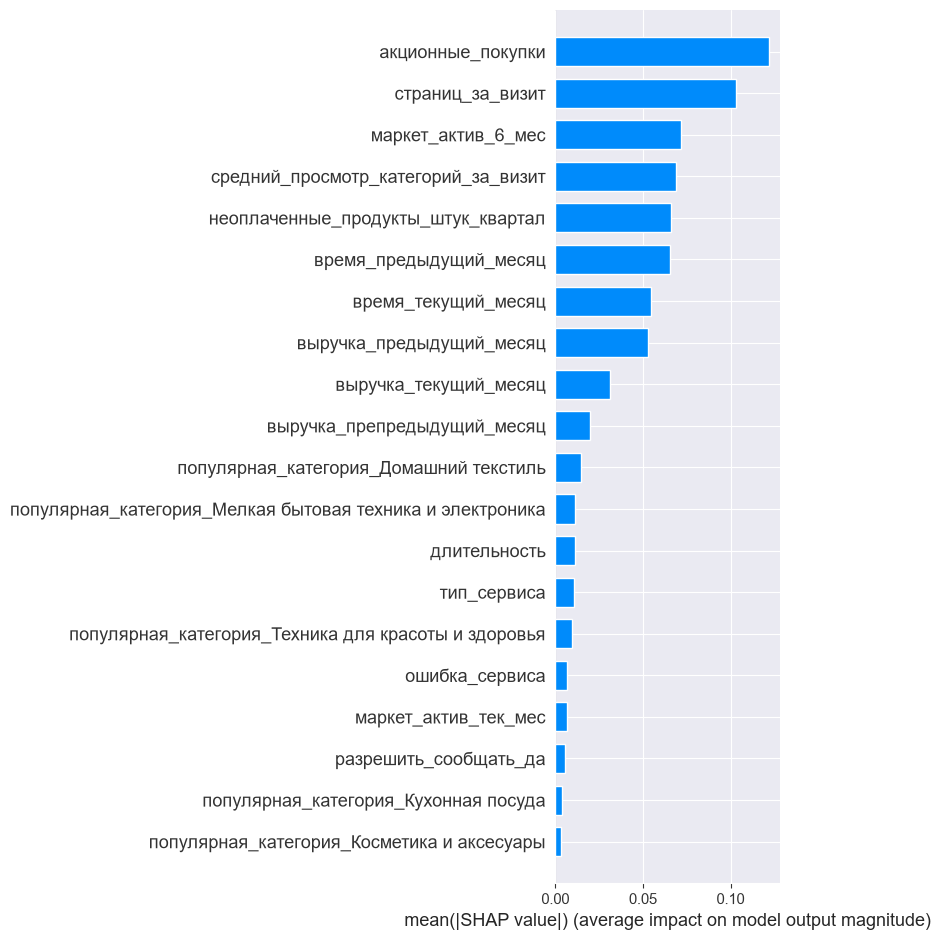

In [241]:
final_model = randomized_search.best_estimator_

preprocessor = final_model.named_steps['preprocessor']

ohe_encoder = preprocessor.named_transformers_['ohe'].named_steps['ohe']
#ord_encoer = preprocessor.named_transformers_['ord'].named_steps['ord']

ohe_feature_names = ohe_encoder.get_feature_names_out(ohe_columns)
ord_feature_names = ord_columns

all_feature_names = list(ohe_feature_names) + ord_feature_names + num_columns

X_test_prep = final_model.named_steps['preprocessor'].transform(X_test)
X_test_prep_df = pd.DataFrame(X_test_prep, columns=all_feature_names)

final_clf = final_model.named_steps['models']

explainer = shap.Explainer(final_clf.predict, X_test_prep_df)
shap_values = explainer(X_test_prep_df)

shap.summary_plot(shap_values.values, X_test_prep_df, plot_type="bar")


**Most influential features:**

- Promotional purchases,


- Average category views per visit, 


- Marketing activity over 6 months

**Least significant features:** 

- Popular category: kitchenware / children's goods,


- Mailing list permission

### Step 8. Customer Segmentation

In [242]:
profitable_users = X[(X['акционные_покупки'] > X['акционные_покупки'].median())
               &
               (X['средний_просмотр_категорий_за_визит'] > X['средний_просмотр_категорий_за_визит'].median())
               &
               (X['маркет_актив_6_мес'] > X['маркет_актив_6_мес'].median())]

print(f'Number of clients in the segment: {profitable_users.shape[0]}')
print(f'Share of clients in the segment: {profitable_users.shape[0] / X.shape[0] * 100:.2f}%')

Number of clients in the segment: 103
Share of clients in the segment: 7.94%


**As part of user segmentation, a high purchasing activity segment was identified.**

**The segment includes users who have:**

- A high number of promotional purchases


- High engagement (average category views per visit)


- High marketing activity over the past 6 months

In [243]:

segment_X = profitable_users.copy()
segment_prep = final_model.named_steps['preprocessor'].transform(segment_X)

segment_proba = final_model.named_steps['models'].predict_proba(segment_prep)[:, 1]

threshold = 0.5
low_activity_users = segment_X[segment_proba < threshold]
high_activity_users = segment_X[segment_proba >= threshold]


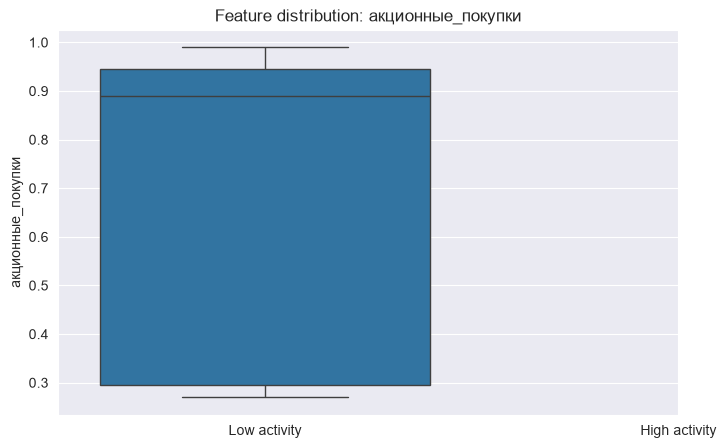

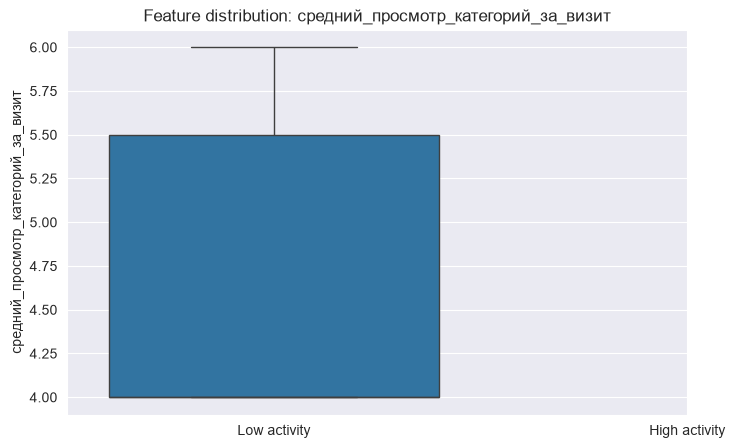

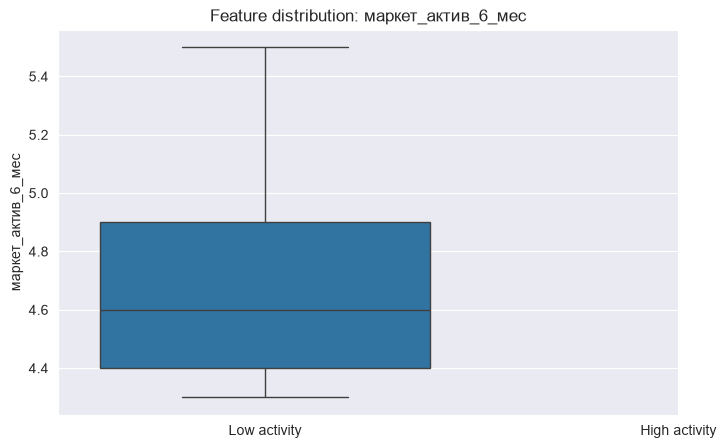

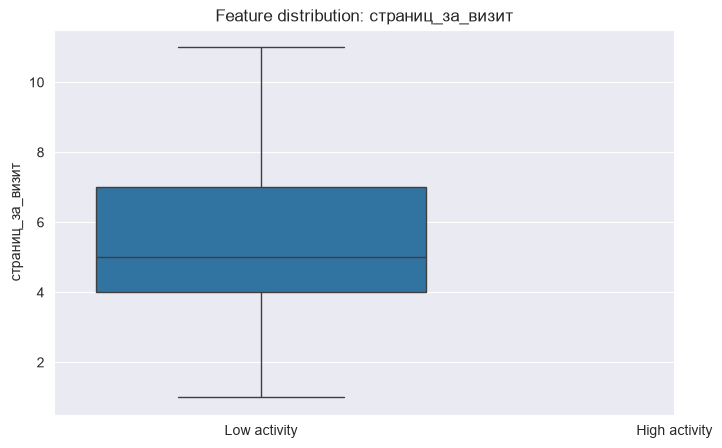

In [244]:
features = ['акционные_покупки', 'средний_просмотр_категорий_за_визит', 
            'маркет_актив_6_мес', 'страниц_за_визит']

for feature in features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=[low_activity_users[feature], high_activity_users[feature]])
    plt.xticks([0, 1], ['Low activity', 'High activity'])
    plt.title(f'Feature distribution: {feature}')
    plt.ylabel(feature)
    plt.show()

**Segment analysis revealed an interesting pattern:**

- Users with a low probability of future activity view more categories and pages per visit, but make fewer promotional purchases.


- Conversely, users with a high probability of activity make more promotional purchases, yet spend less time and view fewer pages.


- This may indicate that promotional offers are the key driver of purchasing activity in this case, rather than overall engagement levels.


- Users with high time spent and high page/category views but low purchase counts are likely experiencing difficulties finding products of interest or are not finding attractive offers.



**Based on this:**

- It is recommended to offer personalized promotions and products that closely match the interests of these users.


- It is important to improve website sections and navigation to guide users to promotional items more quickly.


- Introduce personalized recommendations and notifications for the low-activity probability group to increase the likelihood of purchase.






### General conclusion

**<p style="font-size:16px;">As part of the project for the "One-Click" online store, the objective was set to predict the probability of a decline in purchasing activity among regular customers and to propose personalized recommendations for user retention.</p>**

**Initial Data and Preprocessing:**

- Data from multiple tables was loaded and examined. During preprocessing, missing values were handled, duplicates were removed, data types were corrected, and features were prepared for encoding and scaling.

**Model Selection:**

- Four algorithms were used for modeling: KNeighborsClassifier, DecisionTreeClassifier, LogisticRegression, and SVC. Hyperparameter tuning was performed using RandomizedSearchCV. The best ROC-AUC metric of 0.86 was achieved by the SVC model with a sigmoid kernel (kernel='sigmoid') and regularization C=8.

**Results and Segmentation:**
- Feature importance analysis revealed that the most significant features for the model are: promotional purchases, average category views per visit, and marketing activity over 6 months. Less significant were product category indicators and mailing list permissions.


- A segment of customers with high engagement but a low purchase rate was identified. **For this segment, it is recommended to:**


  - Offer personalized promotions that match user interests.
 
 
  - Improve website navigation and simplify access to promotional items.


  - Introduce personalized recommendations and notifications to increase purchasing activity.


  - Thus, the proposed solution will help retain customers and stimulate their activity through personalized approaches.

